## Install Packages for the Environment via Anaconda

Follow these steps to install new packages:

1. **Activate the Environment**  
   After creating the environment, activate it using:  
   **`conda activate ErSE222`**

2. **Install torchbnn**  
   Once the environment is activated, install torchvision with:  
   **`pip install torchbnn`**  
   *Usage*: torchbnn is a lightweight library designed for building Bayesian neural networks using PyTorch.

# UQ with PyTorch

$f(x)=sin(x)$. 


Given enough pairs $(x,f(x))$ we wish the network to be able to give us a correct estimate of $f(x_i)$ on an unseen $x_i$.

In this tutorial we will implement 3 of such techniques, namely:

- UQ by MC-Dropout;
- UQ by Deep Ensembles;
- UQ by Bayesian Neural Networks.

In one of the subsequent labs we will further extend the second method for non-gaussian probabilities using Mixture Density Networks (MDNs).

In [4]:
%matplotlib inline

import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.distributions as dd
import torchbnn as bnn

from torch.utils.data import TensorDataset, DataLoader 

In [5]:
def set_seed(seed):
    """
    Use this to set ALL the random seeds to a fixed value and take out any randomness from cuda kernels
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled   = False

    return True

## Create dataset

In [6]:
set_seed(5)

True

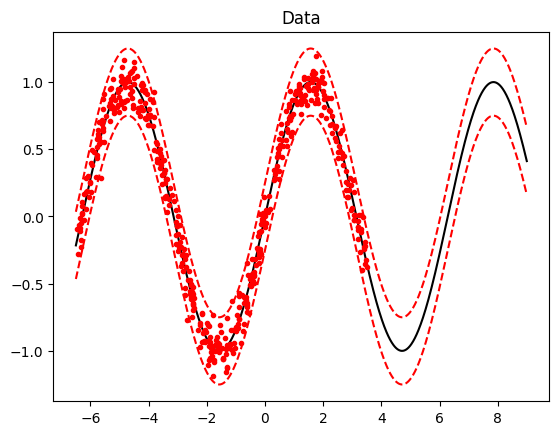

In [42]:
ntrain = 64*8
ntest = 1000
sigma = 0.1 # noise standard deviation

xtrain = torch.rand(ntrain) * 10 - 6.5
xtest = torch.linspace(-6.5, 9., ntest)
noise = sigma * torch.randn(xtrain.shape[0])

ytrain = torch.sin(xtrain) + noise
ytest = torch.sin(xtest)

plt.figure()
plt.plot(xtest, ytest, 'k')
plt.plot(xtrain, ytrain, '.r')
plt.plot(xtest, ytest+2.5*sigma, '--r')
plt.plot(xtest, ytest-2.5*sigma, '--r')
plt.title('Data');

In [43]:
train_dataset = TensorDataset(xtrain, ytrain)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [44]:
ypreds, ystds = {}, {}

## Deterministic Network

In [45]:
class DeepNetwork(nn.Module):
    def __init__(self, I, H, O, drop=0.3):
        super(DeepNetwork, self).__init__()
        self.net =  nn.Sequential(
            nn.Linear(I, H[0], bias=True),
            nn.ReLU(),
            nn.Linear(H[0], H[1], bias=True),
            nn.ReLU(),
            nn.Linear(H[1], O, bias=True))
        
    def forward(self, x):
        return self.net(x)

In [46]:
model = DeepNetwork(1, [20, 50], 1)
model

DeepNetwork(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=1, bias=True)
  )
)

Epoch: 0, Loss: 0.05773481586948037
Epoch: 500, Loss: 0.0039038003305904567
Epoch: 1000, Loss: 0.001907560639665462
Epoch: 1500, Loss: 0.0016018114692997187
Epoch: 2000, Loss: 0.001564451536978595
Epoch: 2500, Loss: 0.0016593946929788217
Epoch: 3000, Loss: 0.001519815115898382
Epoch: 3500, Loss: 0.0015830165357328951
Epoch: 4000, Loss: 0.0016087480616988614
Epoch: 4500, Loss: 0.0014377859843079932


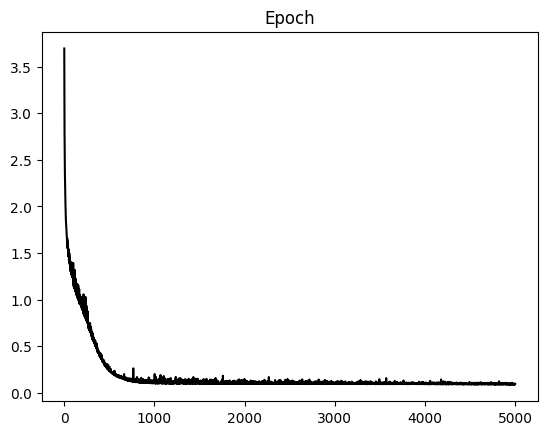

In [47]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
criterion = torch.nn.MSELoss()
n_epochs = 5000

model.train()
loss_hist = []
for epoch in range(n_epochs):
    total_loss = 0.
    for X, y in train_loader:
        optimizer.zero_grad()
        yest = model(X.view(X.shape[0], 1)).squeeze()
        loss = criterion(yest, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_hist.append(total_loss)
    if epoch % (n_epochs//10) == 0:
        print(f'''Epoch: {epoch}, Loss: {total_loss / X.size(0)}''')
        
plt.figure()
plt.plot(loss_hist, 'k')
plt.title('Epoch');

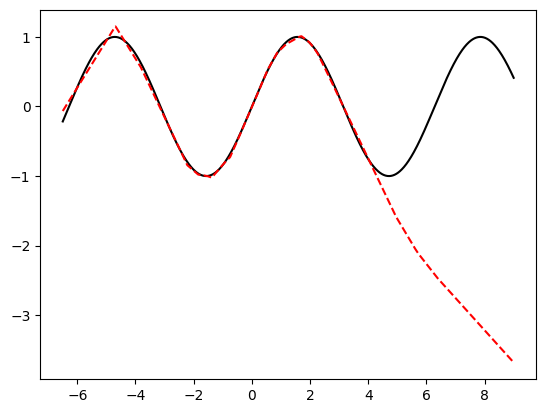

In [48]:
# Prediction
ypred = model(xtest.view(xtest.shape[0], 1)) 
ypreds['Deterministic'] = ypred

plt.figure()
plt.plot(xtest, ytest, 'k')
plt.plot(xtest, ypred.detach().numpy(), '--r');

## Network with Dropout UQ

In [49]:
class DeepDropNetwork(nn.Module):
    def __init__(self, I, H, O, drop=0.3):
        super(DeepDropNetwork, self).__init__()
        self.net =  nn.Sequential(
            nn.Linear(I, H[0], bias=True),
            nn.Dropout(p=drop),
            nn.ReLU(),
            nn.Linear(H[0], H[1], bias=True),
            nn.Dropout(p=drop),
            nn.ReLU(),
            nn.Linear(H[1], O, bias=True))
        
    def forward(self, x):
        return self.net(x)

In [50]:
model = DeepDropNetwork(1, [20, 50], 1, drop=0.01)
model

DeepDropNetwork(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=20, bias=True)
    (1): Dropout(p=0.01, inplace=False)
    (2): ReLU()
    (3): Linear(in_features=20, out_features=50, bias=True)
    (4): Dropout(p=0.01, inplace=False)
    (5): ReLU()
    (6): Linear(in_features=50, out_features=1, bias=True)
  )
)

Epoch: 0, Loss: 0.06518499460071325
Epoch: 500, Loss: 0.003554265305865556
Epoch: 1000, Loss: 0.002641473722178489
Epoch: 1500, Loss: 0.001965019677300006
Epoch: 2000, Loss: 0.0021487875055754557
Epoch: 2500, Loss: 0.0021742507233284414
Epoch: 3000, Loss: 0.0017556458624312654
Epoch: 3500, Loss: 0.001978327360120602
Epoch: 4000, Loss: 0.0016282387223327532
Epoch: 4500, Loss: 0.0020349746628198773


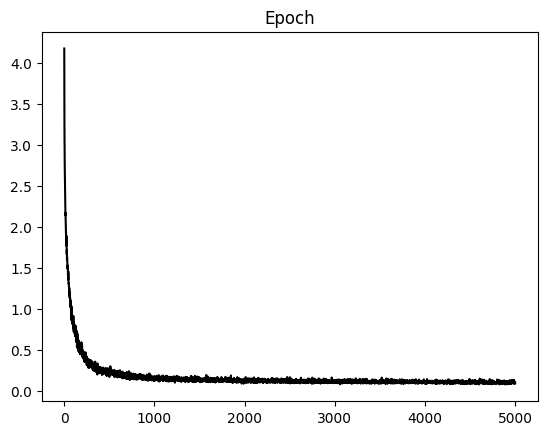

In [51]:
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)
criterion = torch.nn.MSELoss()
n_epochs = 5000

model.train()
loss_hist = []
for epoch in range(n_epochs):
    total_loss = 0.
    for X, y in train_loader:
        optimizer.zero_grad()
        yest = model(X.view(X.shape[0], 1)).squeeze() 
        loss = criterion(yest, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    loss_hist.append(total_loss)
    if epoch % (n_epochs//10) == 0:
        print(f'''Epoch: {epoch}, Loss: {total_loss / X.size(0)}''')

plt.figure()
plt.plot(loss_hist, 'k')
plt.title('Epoch');

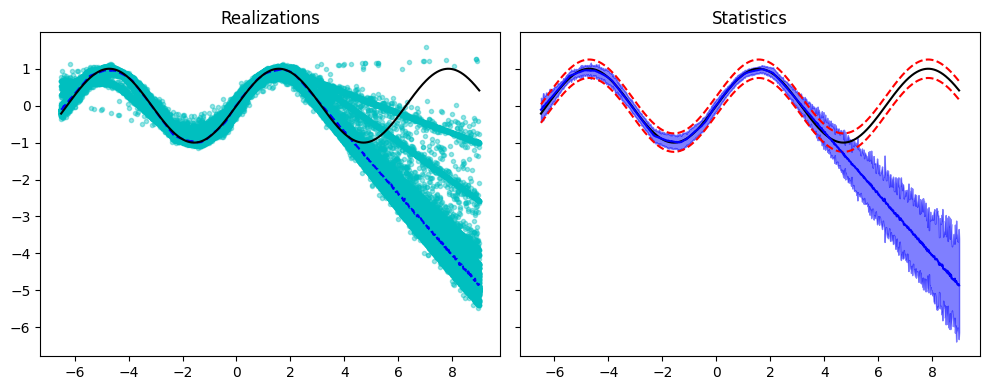

In [55]:
nreals = 400
yreals = np.hstack([model(xtest.view(xtest.shape[0], 1)).detach().numpy() for _ in range(nreals)])

ypred = yreals.mean(axis=1)
ystd = yreals.std(axis=1)
ypreds['Dropout'] = ypred
ystds['Dropout'] = ystd

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
axs[0].plot(xtest, yreals, '.c', alpha=0.4)
axs[0].plot(xtest, ypred, '--b')
axs[0].plot(xtest, ytest, 'k')
axs[0].set_title('Realizations')
axs[1].plot(xtest, ytest, 'k')
axs[1].plot(xtest, ytest+2.5*sigma, '--r')
axs[1].plot(xtest, ytest-2.5*sigma, '--r')
axs[1].plot(xtest, ypred, 'b')
axs[1].fill_between(xtest, ypred - 2.5*ystd, ypred + 2.5*ystd,
                    alpha=0.5, color='b')
axs[1].set_title('Statistics')
fig.tight_layout();

## Deep Ensemble Network UQ

Training model 0/10
Epoch: 0, Loss: 0.05498688481748104
Epoch: 200, Loss: 0.009180771536193788
Epoch: 400, Loss: 0.002846420422429219
Epoch: 600, Loss: 0.001542602592962794
Epoch: 800, Loss: 0.0018559614109108225
Epoch: 1000, Loss: 0.0012468793865991756
Epoch: 1200, Loss: 0.001220607606228441
Epoch: 1400, Loss: 0.0013048263499513268
Epoch: 1600, Loss: 0.001279034469916951
Epoch: 1800, Loss: 0.0011800995416706428
Training model 1/10
Epoch: 0, Loss: 0.0649603744968772
Epoch: 200, Loss: 0.014792719040997326
Epoch: 400, Loss: 0.010220781259704381
Epoch: 600, Loss: 0.004211293067783117
Epoch: 800, Loss: 0.0033617109584156424
Epoch: 1000, Loss: 0.0017319613689323887
Epoch: 1200, Loss: 0.002691779605811462
Epoch: 1400, Loss: 0.00314438552595675
Epoch: 1600, Loss: 0.001553337584482506
Epoch: 1800, Loss: 0.0013237919774837792
Training model 2/10
Epoch: 0, Loss: 0.06436270987614989
Epoch: 200, Loss: 0.008536185836419463
Epoch: 400, Loss: 0.003961107257055119
Epoch: 600, Loss: 0.00320453573658596

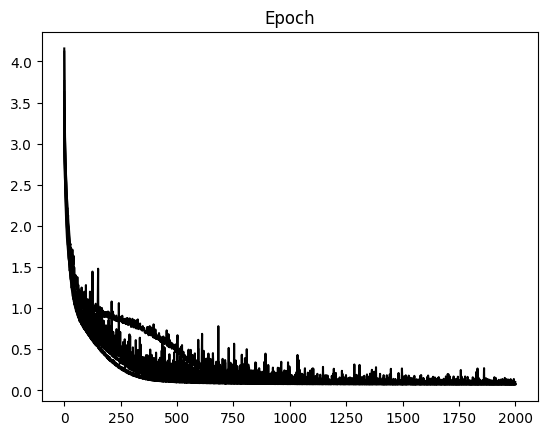

In [56]:
criterion = torch.nn.MSELoss()
n_epochs = 2000
n_models = 10

models = []
loss_hists = []
for i in range(n_models):
    print(f'Training model {i}/{n_models}')
    model = DeepNetwork(1, [20, 50], 1)
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

    model.train()
    loss_hist = []
    for epoch in range(n_epochs):
        total_loss = 0.
        for X, y in train_loader:
            optimizer.zero_grad()
            yest = model(X.view(X.shape[0], 1)).squeeze()
            loss = criterion(yest, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        loss_hist.append(total_loss)
        if epoch % (n_epochs//10) == 0:
            print(f'Epoch: {epoch}, Loss: {total_loss / X.size(0)}')
    loss_hists.append(loss_hist)
    models.append(model)
    
plt.figure()
plt.plot(np.array(loss_hists).T, 'k')
plt.title('Epoch');

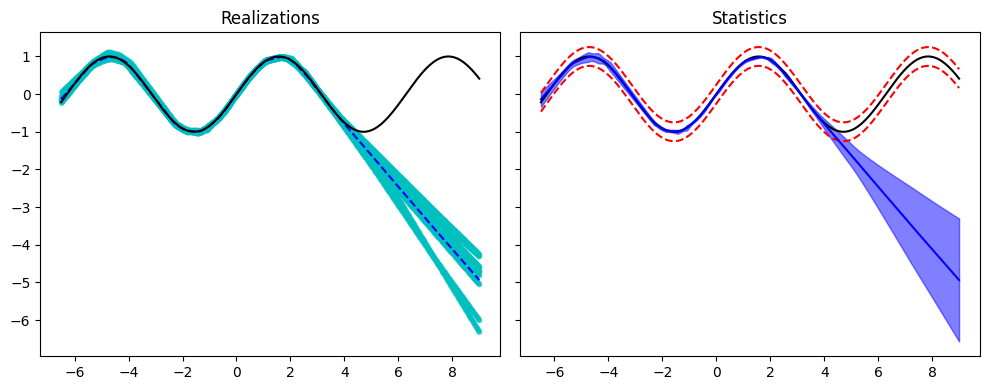

In [59]:
# Prediction
yreals = np.hstack([model(xtest.view(xtest.shape[0], 1)).detach().numpy() for model in models])

ypred = yreals.mean(axis=1)
ystd = yreals.std(axis=1)
ypreds['Ensemble'] = ypred
ystds['Ensemble'] = ystd

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
axs[0].plot(xtest, yreals, '.c', alpha=0.4)
axs[0].plot(xtest, ypred, '--b')
axs[0].plot(xtest, ytest, 'k')
axs[0].set_title('Realizations')
axs[1].plot(xtest, ytest, 'k')
axs[1].plot(xtest, ytest+2.5*sigma, '--r')
axs[1].plot(xtest, ytest-2.5*sigma, '--r')
axs[1].plot(xtest, ypred, 'b')
axs[1].fill_between(xtest, ypred - 2.5*ystd, ypred + 2.5*ystd,
                    alpha=0.5, color='b')
axs[1].set_title('Statistics')
fig.tight_layout();


## Bayesian Network

In [60]:
class BayesianNetwork(nn.Module):
    def __init__(self, I, H, O):
        super(BayesianNetwork, self).__init__()
        self.net =  nn.Sequential(
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=I, out_features=H[0]),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=H[0], out_features=H[1]),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=H[1], out_features=O))
        
    def forward(self, x):
        return self.net(x)

In [61]:
model = BayesianNetwork(1, [20, 50], 1)
model

BayesianNetwork(
  (net): Sequential(
    (0): BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=1, out_features=20, bias=True)
    (1): ReLU()
    (2): BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=20, out_features=50, bias=True)
    (3): ReLU()
    (4): BayesLinear(prior_mu=0, prior_sigma=0.1, in_features=50, out_features=1, bias=True)
  )
)

Epoch: 0, Loss: 0.41618430614471436, MSE: 0.4019320011138916, KL: 1.4252313375473022
Epoch: 500, Loss: 0.07934671640396118, MSE: 0.06200374662876129, KL: 1.7342971563339233
Epoch: 1000, Loss: 0.06350026279687881, MSE: 0.0465710386633873, KL: 1.6929227113723755
Epoch: 1500, Loss: 0.04269370436668396, MSE: 0.02785773202776909, KL: 1.4835971593856812
Epoch: 2000, Loss: 0.03060786798596382, MSE: 0.01759449578821659, KL: 1.3013373613357544
Epoch: 2500, Loss: 0.02695808932185173, MSE: 0.015293514356017113, KL: 1.1664576530456543
Epoch: 3000, Loss: 0.02276267483830452, MSE: 0.012040577828884125, KL: 1.0722095966339111
Epoch: 3500, Loss: 0.02182498201727867, MSE: 0.01183799747377634, KL: 0.9986985325813293
Epoch: 4000, Loss: 0.021251000463962555, MSE: 0.011690771207213402, KL: 0.9560230374336243
Epoch: 4500, Loss: 0.019864093512296677, MSE: 0.01065681129693985, KL: 0.9207282066345215


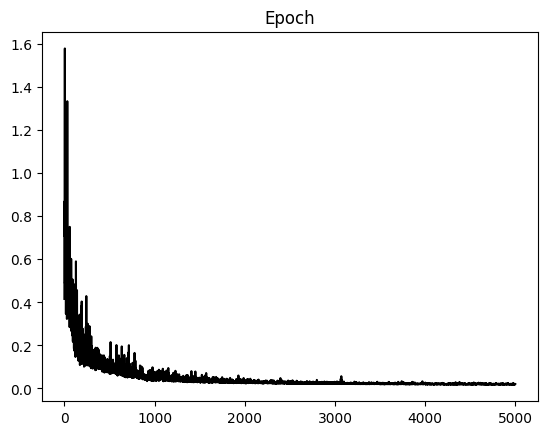

In [62]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
mse_loss = nn.MSELoss()
kl_loss = bnn.BKLLoss(reduction='mean', last_layer_only=False)
kl_weight = 0.01
n_epochs = 5000

model.train()
loss_hist = []
for epoch in range(n_epochs):
    optimizer.zero_grad()
    yest = model(xtrain.view(xtrain.shape[0], 1)).squeeze() 
    mse = mse_loss(yest, ytrain)
    kl = kl_loss(model)
    loss = mse + kl_weight*kl
    loss.backward()
    optimizer.step()
    loss_hist.append(loss.item())
    
    if epoch % (n_epochs//10) == 0:
        print(f'''Epoch: {epoch}, Loss: {loss.item()}, MSE: {mse.item()}, KL: {kl.item()}''')

plt.figure()
plt.plot(loss_hist, 'k')
plt.title('Epoch');

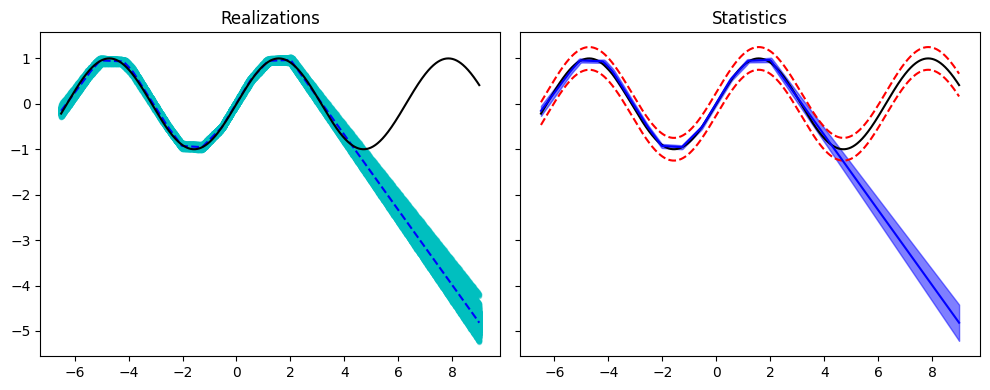

In [63]:
# Prediction
nreals = 400
yreals = np.hstack([model(xtest.view(xtest.shape[0], 1)).detach().numpy() for _ in range(nreals)])

ypred = yreals.mean(axis=1)
ystd = yreals.std(axis=1)
ypreds['BayesianNN'] = ypred
ystds['BayesianNN'] = ystd

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 4))
axs[0].plot(xtest, yreals, '.c', alpha=0.4)
axs[0].plot(xtest, ypred, '--b')
axs[0].plot(xtest, ytest, 'k')
axs[0].set_title('Realizations')
axs[1].plot(xtest, ytest, 'k')
axs[1].plot(xtest, ytest+2.5*sigma, '--r')
axs[1].plot(xtest, ytest-2.5*sigma, '--r')
axs[1].plot(xtest, ypred, 'b')
axs[1].fill_between(xtest.squeeze(), ypred - 2.5*ystd, ypred + 2.5*ystd,
                    alpha=0.5, color='b')
axs[1].set_title('Statistics')
fig.tight_layout();

Finally, let's compare the different predictions (and their uncertainties)

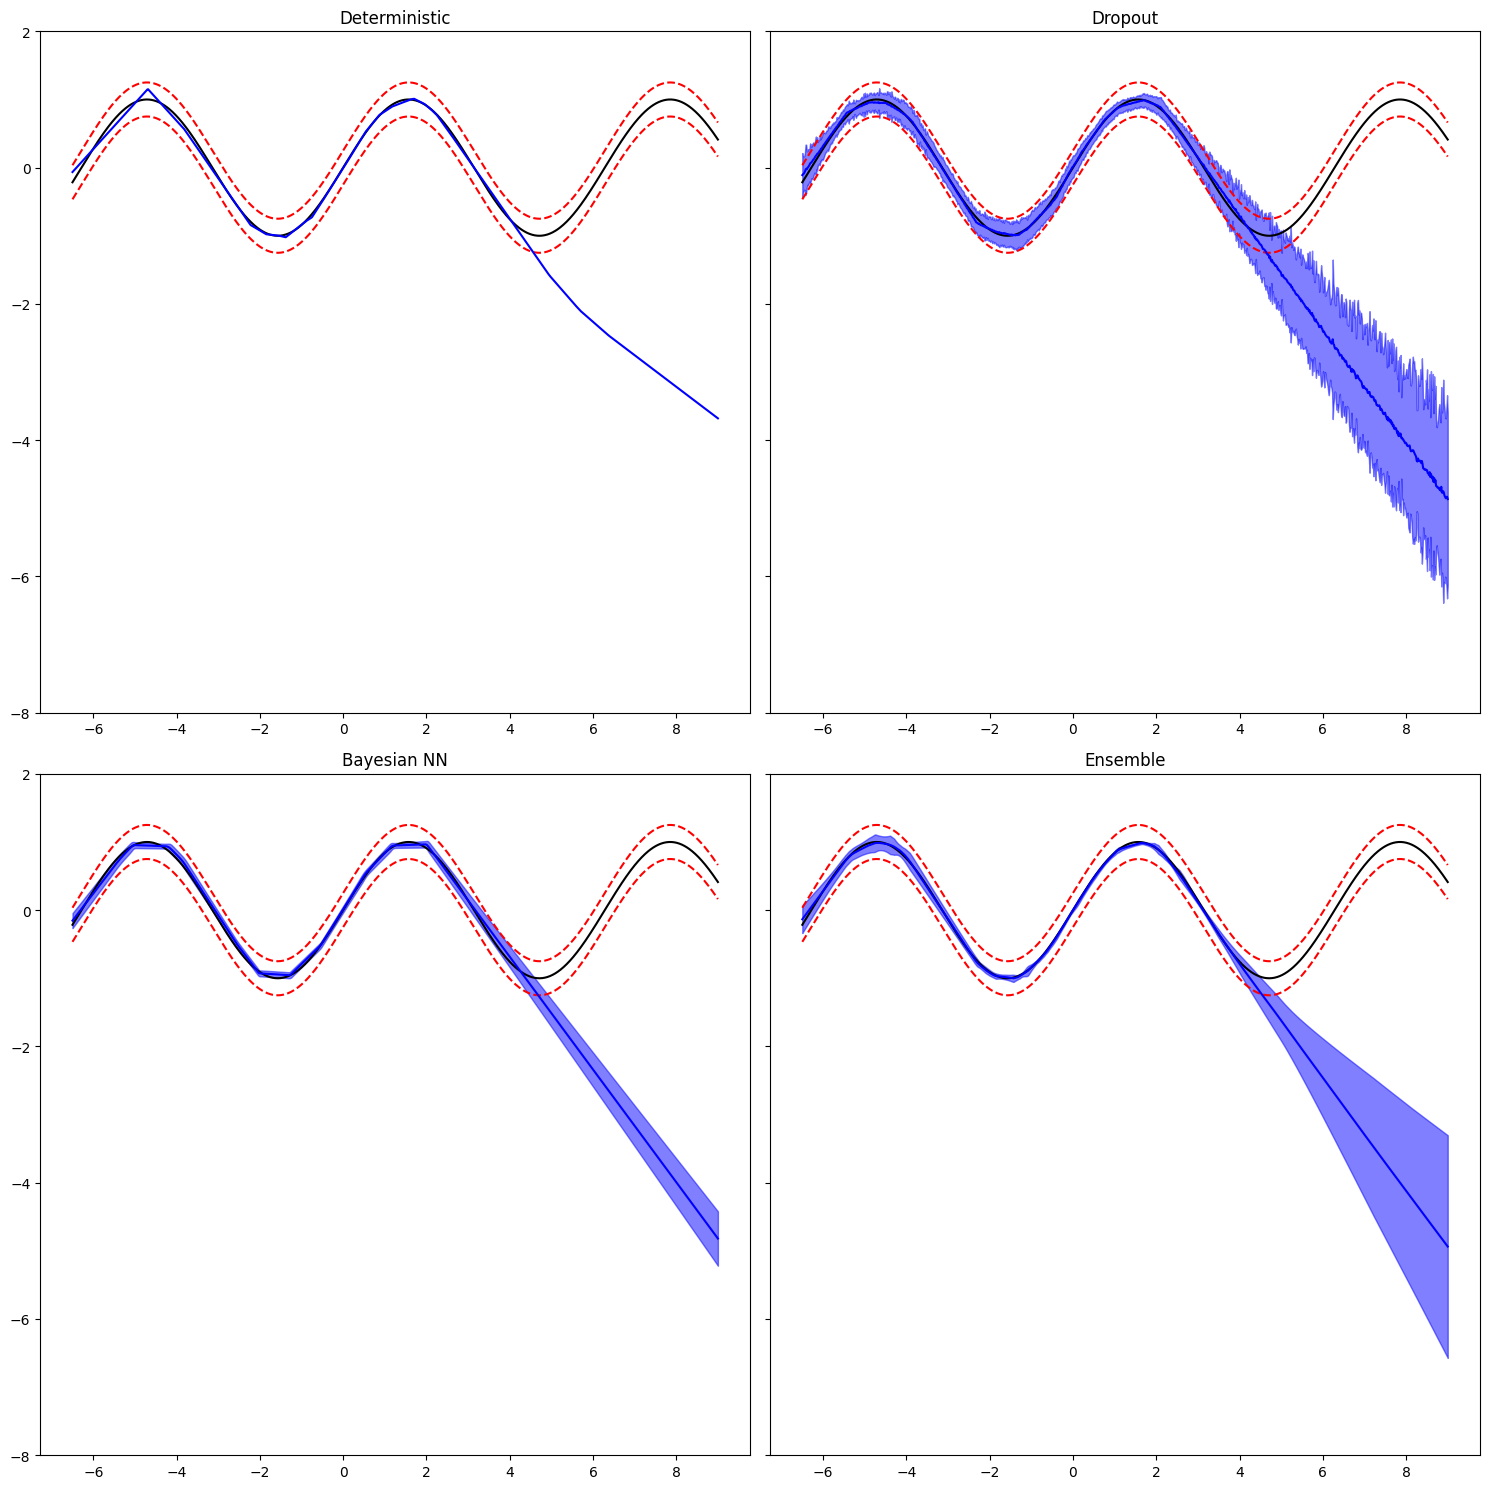

In [68]:
fig, axs = plt.subplots(2, 2, sharey=True, figsize=(15, 15))
axs[0][0].plot(xtest, ytest, 'k')
axs[0][0].plot(xtest, ytest+2.5*sigma, '--r')
axs[0][0].plot(xtest, ytest-2.5*sigma, '--r')
axs[0][0].plot(xtest, ypreds['Deterministic'].detach().numpy(), 'b')
axs[0][0].set_title('Deterministic')
axs[0][1].plot(xtest, ytest, 'k')
axs[0][1].plot(xtest, ytest+2.5*sigma, '--r')
axs[0][1].plot(xtest, ytest-2.5*sigma, '--r')
axs[0][1].plot(xtest, ypreds['Dropout'], 'b')
axs[0][1].fill_between(xtest, ypreds['Dropout'] - 2.5*ystds['Dropout'], 
                       ypreds['Dropout'] + 2.5*ystds['Dropout'],
                       alpha=0.5, color='b')
axs[0][1].set_title('Dropout')
axs[1][1].plot(xtest, ytest, 'k')
axs[1][1].plot(xtest, ytest+2.5*sigma, '--r')
axs[1][1].plot(xtest, ytest-2.5*sigma, '--r')
axs[1][1].plot(xtest, ypreds['Ensemble'], 'b')
axs[1][1].fill_between(xtest, ypreds['Ensemble'] - 2.5*ystds['Ensemble'], 
                       ypreds['Ensemble'] + 2.5*ystds['Ensemble'],
                       alpha=0.5, color='b')
axs[1][1].set_title('Ensemble')
axs[1][0].plot(xtest, ytest, 'k')
axs[1][0].plot(xtest, ytest+2.5*sigma, '--r')
axs[1][0].plot(xtest, ytest-2.5*sigma, '--r')
axs[1][0].plot(xtest, ypreds['BayesianNN'], 'b')
axs[1][0].fill_between(xtest, ypreds['BayesianNN'] - 2.5*ystds['BayesianNN'], 
                       ypreds['BayesianNN'] + 2.5*ystds['BayesianNN'],
                       alpha=0.5, color='b')
axs[1][0].set_title('Bayesian NN')
axs[0][0].set_ylim(-8, 2)
#axs[2][1].axis('off')
fig.tight_layout();